<a href="https://colab.research.google.com/github/Dakshaayini/northstar-analytics/blob/main/Copy_of_02_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Load all NorthStar CSV files
customers  <- read.csv('customers.csv',  stringsAsFactors=FALSE)
orders     <- read.csv('orders.csv',     stringsAsFactors=FALSE)
deliveries <- read.csv('deliveries.csv', stringsAsFactors=FALSE)
drivers    <- read.csv('drivers.csv',    stringsAsFactors=FALSE)
vehicles   <- read.csv('vehicles.csv',   stringsAsFactors=FALSE)
hubs       <- read.csv('hubs.csv',       stringsAsFactors=FALSE)
incidents  <- read.csv('incidents.csv',  stringsAsFactors=FALSE)
complaints <- read.csv('complaints.csv', stringsAsFactors=FALSE)

In [ ]:
# Cell 2: Inspect the main delivery file
cat('Orders:', nrow(orders), '| Deliveries:', nrow(deliveries), '\n')
cat('Complaints:', nrow(complaints), '| Incidents:', nrow(incidents), '\n')
head(deliveries, 3)
str(deliveries)


Orders: 1250 | Deliveries: 950 
Complaints: 320 | Incidents: 280 


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51


'data.frame':	950 obs. of  13 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr  "O00938" "O00004" "O00639" "O00313" ...
 $ driver_id                    : chr  "D004" "D138" "D006" "D116" ...
 $ vehicle_id                   : chr  "V056" "V007" "V049" "V055" ...
 $ hub_id                       : chr  "H05" "H02" "H02" "H02" ...
 $ dispatch_time                : chr  "2024-06-18 10:57:00" "2025-01-11 18:45:00" "2025-06-02 20:39:00" "2024-03-08 23:31:00" ...
 $ delivery_completed_at        : chr  "2024-06-19 09:05:59.904311" "2025-01-11 17:39:00.000000" "2025-06-02 21:45:32.366770" "2024-03-09 23:30:08.103702" ...
 $ delivery_status              : chr  "Failed" "OnTime" "OnTime" "Delayed" ...
 $ route_distance_km            : num  17.26 10.34 7.92 16.42 14.52 ...
 $ manual_route_override_count  : int  1 1 0 0 1 0 0 1 1 1 ...
 $ proof_of_completion_missing  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ customer_rating_p

In [ ]:
# Cell 3: Full statistical summary
summary(deliveries[, c('manual_route_override_count',
                       'customer_rating_post_delivery',
                       'fuel_or_charge_cost',
                       'route_distance_km')])

 manual_route_override_count customer_rating_post_delivery fuel_or_charge_cost
 Min.   :0.0000              Min.   :1.000                 Min.   : 2.500     
 1st Qu.:0.0000              1st Qu.:3.360                 1st Qu.: 9.925     
 Median :1.0000              Median :4.040                 Median :12.645     
 Mean   :0.9695              Mean   :3.865                 Mean   :12.841     
 3rd Qu.:2.0000              3rd Qu.:4.550                 3rd Qu.:15.697     
 Max.   :7.0000              Max.   :5.000                 Max.   :29.430     
                             NAs    :14                                       
 route_distance_km
 Min.   : 1.200   
 1st Qu.: 9.135   
 Median :12.840   
 Mean   :13.909   
 3rd Qu.:16.835   
 Max.   :41.940   
                  

In [ ]:
# Cell 4: Correlation matrix on numeric columns
num_cols   <- deliveries[, sapply(deliveries, is.numeric)]
cor_matrix <- cor(num_cols, use='complete.obs')
print(round(cor_matrix, 3))

                              route_distance_km manual_route_override_count
route_distance_km                         1.000                       0.199
manual_route_override_count               0.199                       1.000
proof_of_completion_missing               0.022                       0.041
customer_rating_post_delivery             0.029                      -0.060
fuel_or_charge_cost                       0.527                       0.099
                              proof_of_completion_missing
route_distance_km                                   0.022
manual_route_override_count                         0.041
proof_of_completion_missing                         1.000
customer_rating_post_delivery                      -0.218
fuel_or_charge_cost                                 0.057
                              customer_rating_post_delivery fuel_or_charge_cost
route_distance_km                                     0.029               0.527
manual_route_override_count         

In [ ]:
# Cell 5: T-test — is Failed delivery rating significantly lower?
rating_failed <- deliveries$customer_rating_post_delivery[deliveries$delivery_status=='Failed']
rating_ontime <- deliveries$customer_rating_post_delivery[deliveries$delivery_status=='OnTime']
cat('Mean rating - Failed: ', round(mean(rating_failed, na.rm=TRUE),2), '\n')
cat('Mean rating - OnTime:', round(mean(rating_ontime, na.rm=TRUE),2), '\n')
t.test(rating_failed, rating_ontime, alternative='less')

Mean rating - Failed:  3.05 
Mean rating - OnTime: 4.28 



	Welch Two Sample t-test

data:  rating_failed and rating_ontime
t = -15.483, df = 150.91, p-value < 2.2e-16
alternative hypothesis: true difference in means is less than 0
95 percent confidence interval:
      -Inf -1.102061
sample estimates:
mean of x mean of y 
 3.049313  4.283273 


In [ ]:
# Cell 6: dplyr — service type performance
library(dplyr)
svc_summary <- deliveries %>%
  left_join(orders, by='order_id') %>%
  group_by(service_type) %>%
  summarise(
    total         = n(),
    failed        = sum(delivery_status=='Failed', na.rm=TRUE),
    failure_rate  = round(100*mean(delivery_status=='Failed',na.rm=TRUE),1),
    avg_rating    = round(mean(customer_rating_post_delivery,na.rm=TRUE),2),
    avg_overrides = round(mean(manual_route_override_count,na.rm=TRUE),2)
  ) %>%
  arrange(desc(failure_rate))
print(svc_summary)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# A tibble: 5 × 6
  service_type total failed failure_rate avg_rating avg_overrides
  <chr>        <int>  <int>        <dbl>      <dbl>         <dbl>
1 Business       126     25         19.8       3.85          1.17
2 Medical        108     16         14.8       3.84          0.84
3 Passenger      262     38         14.5       3.85          0.87
4 Retail         224     28         12.5       3.87          0.94
5 Parcel         230     25         10.9       3.9           1.06


In [ ]:
# Cell 7: Calculate failure rate by pickup zone
library(dplyr)
q1_zone <- deliveries %>%
  left_join(hubs, by='hub_id') %>%
  group_by(zone) %>%
  summarise(
    total_deliveries = n(),
    failed_count     = sum(delivery_status=='Failed', na.rm=TRUE),
    delayed_count    = sum(delivery_status=='Delayed', na.rm=TRUE),
    failure_rate_pct = round(100 * mean(delivery_status=='Failed', na.rm=TRUE), 1),
    avg_rating       = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2)
  ) %>%
  arrange(desc(failure_rate_pct))
print(q1_zone)

# A tibble: 7 × 6
  zone   total_deliveries failed_count delayed_count failure_rate_pct avg_rating
  <chr>             <int>        <int>         <int>            <dbl>      <dbl>
1 Centr…              243           49            47             20.2       3.78
2 Airpo…              104           15            27             14.4       3.88
3 West                127           16            28             12.6       3.92
4 North               136           17            26             12.5       3.84
5 River…              115           14            25             12.2       3.88
6 South               106           10            26              9.4       3.95
7 East                119           11            23              9.2       3.9 


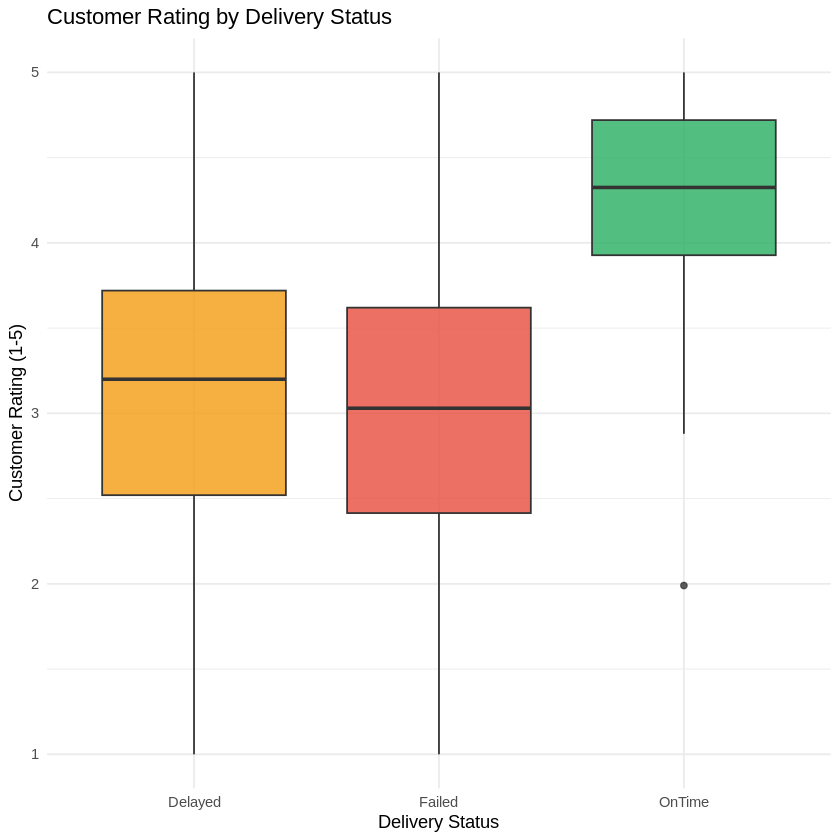

In [ ]:
# Cell 8: Boxplot — customer rating by delivery status
ggplot(deliveries[!is.na(deliveries$customer_rating_post_delivery),],
       aes(x=delivery_status, y=customer_rating_post_delivery, fill=delivery_status)) +
  geom_boxplot(alpha=0.8) +
  scale_fill_manual(values=c('Failed'='#E74C3C','Delayed'='#F39C12','OnTime'='#27AE60')) +
  labs(title='Customer Rating by Delivery Status',
       x='Delivery Status', y='Customer Rating (1-5)') +
  theme_minimal() + theme(legend.position='none')